# Descriptive Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
data = {
    'Student': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Mathematics': [85, 78, 92, 88, 70, 95, 60, 80, 90, 76],
    'Science': [80, 85, 88, 70, 75, 92, 55, 82, 89, 78],
    'English': [78, 74, 85, 80, 68, 90, 50, 77, 83, 72]
}

df = pd.DataFrame(data)

In [3]:
df

,Student,Mathematics,Science,English
0,A,85,80,78
1,B,78,85,74
2,C,92,88,85
3,D,88,70,80
4,E,70,75,68
5,F,95,92,90
6,G,60,55,50
7,H,80,82,77
8,I,90,89,83
9,J,76,78,72


In [4]:
df.describe()


,Mathematics,Science,English
count,10.000000,10.000000,10.000000
mean,81.400000,79.400000,75.700000
std,10.844353,10.895463,11.086027
min,60.000000,55.000000,50.000000
25%,76.500000,75.750000,72.500000
50%,82.500000,81.000000,77.500000
75%,89.500000,87.250000,82.250000
max,95.000000,92.000000,90.000000


In [6]:
df.isnull().sum()

Student        0
Mathematics    0
Science        0
English        0
dtype: int64

In [7]:
df.dtypes

Student        object
Mathematics     int64
Science         int64
English         int64
dtype: object

In [8]:
quan, qual = [], []
for columnName in df.columns:
    if df[columnName].dtype =='O':
        qual.append(columnName)
    else:
        quan.append(columnName)

In [9]:
qual,quan

(['Student'], ['Mathematics', 'Science', 'English'])

# Creating descriptive analysis table

In [10]:
dataset=df.copy()

In [11]:
# 99 percentile
#percentile
#percentile
descriptive = pd.DataFrame( columns = quan ,index=['Mean', 'Median', 'Mode', "Q1:25%", "Q2:50%", "Q3:75%", "99%","Q4:100%", "IQR", "1.5rule", "Lesser", "Greater", "min", "max"])
for columnName in quan:
    descriptive.loc["Mean", columnName] = dataset[columnName].mean()
    descriptive.loc["Median", columnName] = dataset[columnName].median()
    descriptive.loc["Mode", columnName] = dataset[columnName].mode()[0]
    descriptive.loc["Q1:25%", columnName] = dataset.describe()[columnName]["25%"]
    descriptive.loc["Q2:50%", columnName] = dataset.describe()[columnName]["50%"]
    descriptive.loc["Q3:75%", columnName] = dataset.describe()[columnName]["75%"]
    descriptive.loc["Q4:100%", columnName] = dataset.describe()[columnName]["max"]
    descriptive.loc["99%", columnName] = np.percentile(dataset[columnName],99)
    descriptive.loc["IQR", columnName] = descriptive[columnName]["Q3:75%"] - descriptive[columnName]["Q1:25%"]#descriptive.loc["Q3:75%", columnName] - descriptive.loc["Q1:25%", columnName]
    descriptive.loc["1.5rule", columnName] = 1.5 *  descriptive.loc["IQR", columnName]
    # 1.5 rule = 1.5 * IQR
    # lesser formula -->  Q1 - (1.5 * IQR)  ie. Q1 - 1.5rule
    descriptive.loc["Lesser", columnName] =  descriptive[columnName]["Q1:25%"] - descriptive.loc["1.5rule", columnName]  
    descriptive.loc["Greater", columnName] = descriptive[columnName]["Q3:75%"] + descriptive.loc["1.5rule", columnName]  # Q3 + 1.5 * IQR
    descriptive.loc["min", columnName] = dataset[columnName].min()
    descriptive.loc["max", columnName] = dataset[columnName].max()

In [12]:
descriptive

,Mathematics,Science,English
Mean,81.4,79.4,75.7
Median,82.5,81.0,77.5
Mode,60,55,50
Q1:25%,76.5,75.75,72.5
Q2:50%,82.5,81.0,77.5
Q3:75%,89.5,87.25,82.25
99%,94.73,91.73,89.55
Q4:100%,95.0,92.0,90.0
IQR,13.0,11.5,9.75
1.5rule,19.5,17.25,14.625


# Measure of spread

In [13]:
dataset[quan].corr()

,Mathematics,Science,English
Mathematics,1.000000,0.792185,0.974318
Science,0.792185,1.000000,0.874999
English,0.974318,0.874999,1.000000


In [ ]:
Mathematics and english are highly correlated.

In [14]:
dataset[quan].cov()

,Mathematics,Science,English
Mathematics,117.600000,93.600000,117.133333
Science,93.600000,118.711111,105.688889
English,117.133333,105.688889,122.900000


In [ ]:
#example
range_val = df['Science'].max() - df['Science'].min()
variance = df['Science'].var()
std_dev = df['Science'].std()

print("Range:", range_val)
print("Variance:", variance)
print("Standard Deviation:", std_dev)


Range: 37
Variance: 118.71111111111112
Standard Deviation: 10.895462868144296


In [17]:
for columnName in quan:
    descriptive.loc["Range", columnName] = dataset[columnName].max() - dataset[columnName].min()
    descriptive.loc["Variance", columnName] = dataset[columnName].var()
    descriptive.loc["Standard Deviation", columnName] = dataset[columnName].std()
    descriptive.loc["Skewness", columnName] = dataset[columnName].skew()
    descriptive.loc["Kurtosis", columnName] = dataset[columnName].kurt()
descriptive

,Mathematics,Science,English
Mean,81.4,79.4,75.7
Median,82.5,81.0,77.5
Mode,60,55,50
Q1:25%,76.5,75.75,72.5
Q2:50%,82.5,81.0,77.5
Q3:75%,89.5,87.25,82.25
99%,94.73,91.73,89.55
Q4:100%,95.0,92.0,90.0
IQR,13.0,11.5,9.75
1.5rule,19.5,17.25,14.625


# Visual Descriptive Analysis

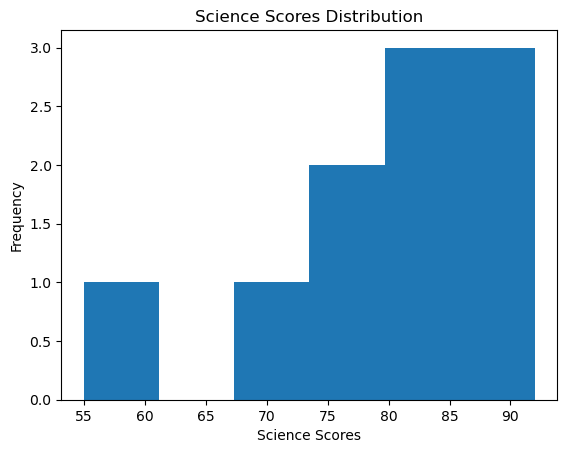

In [20]:
import matplotlib.pyplot as plt

plt.hist(df['Science'], bins=6)
plt.xlabel("Science Scores")
plt.ylabel("Frequency")
plt.title("Science Scores Distribution")
plt.show()


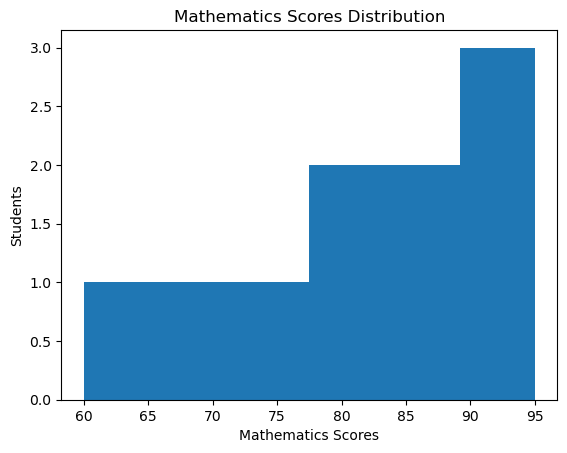

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Mathematics'], bins=6)
plt.xlabel("Mathematics Scores")
plt.ylabel("Frequency")
plt.title("Mathematics Scores Distribution")
plt.show()


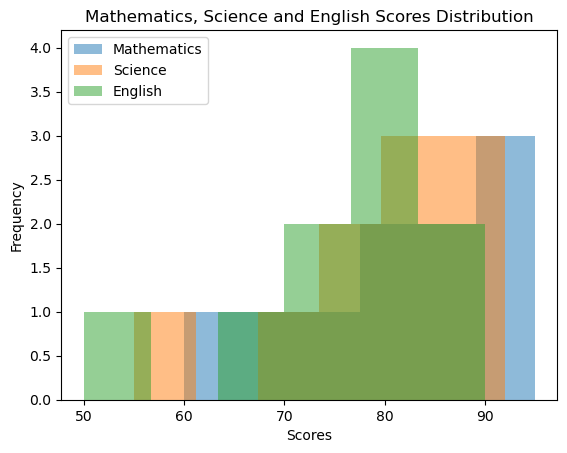

In [28]:
#max of mathematics is 95 and max of science is 92. Hence, the range of mathematics is more than science. Hence, the distribution of mathematics is more spread out than science.
plt.hist(df['Mathematics'], bins=6, alpha=0.5, label='Mathematics')
plt.hist(df['Science'], bins=6, alpha=0.5, label='Science')
plt.hist(df['English'], bins=6, alpha=0.5, label='English')
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.title("Mathematics, Science and English Scores Distribution")
plt.legend()
plt.show()

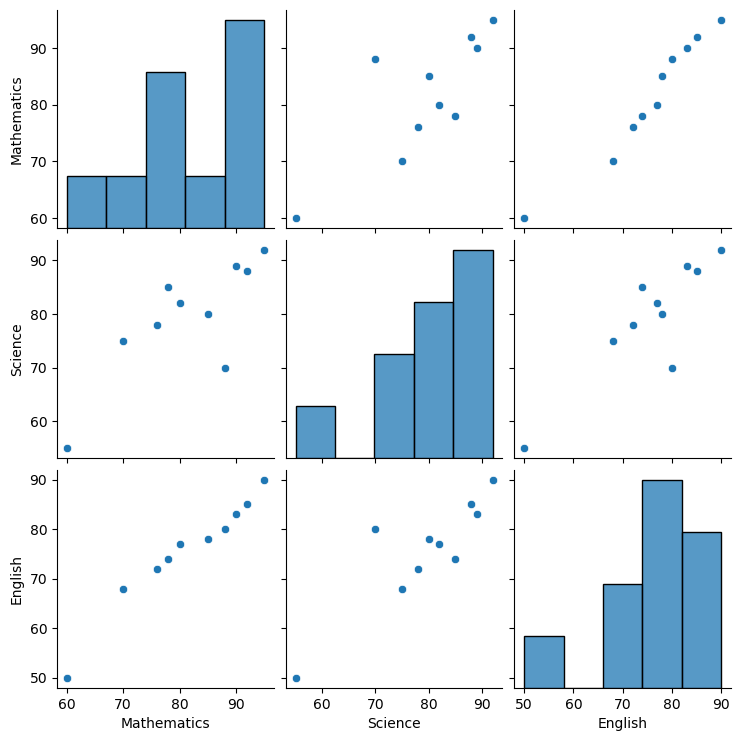

In [38]:
# correlation analysis graph
sns.pairplot(df[quan])
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

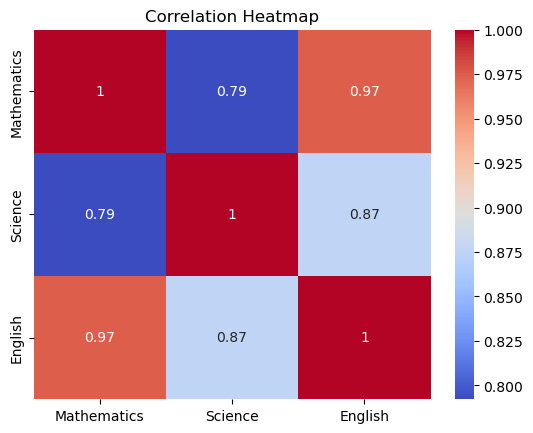

In [39]:
#heatmap
sns.heatmap(df[quan].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

In [30]:
df['Total'] = df[['Mathematics','English','Science']].sum(axis=1)
df['Average'] = df[['Mathematics','English','Science']].mean(axis=1)

In [31]:
df

,Student,Mathematics,Science,English,Total,Average
0,A,85,80,78,243,81.000000
1,B,78,85,74,237,79.000000
2,C,92,88,85,265,88.333333
3,D,88,70,80,238,79.333333
4,E,70,75,68,213,71.000000
5,F,95,92,90,277,92.333333
6,G,60,55,50,165,55.000000
7,H,80,82,77,239,79.666667
8,I,90,89,83,262,87.333333
9,J,76,78,72,226,75.333333


In [34]:
def performance(avg):
    if avg >= 75:
        return "Excellent"
    elif avg >= 50:
        return "Average"
    else:
        return "Needs Improvement"

df['Performance'] = df['Average'].apply(performance)
df

,Student,Mathematics,Science,English,Total,Average,Performance
0,A,85,80,78,243,81.000000,Excellent
1,B,78,85,74,237,79.000000,Excellent
2,C,92,88,85,265,88.333333,Excellent
3,D,88,70,80,238,79.333333,Excellent
4,E,70,75,68,213,71.000000,Average
5,F,95,92,90,277,92.333333,Excellent
6,G,60,55,50,165,55.000000,Average
7,H,80,82,77,239,79.666667,Excellent
8,I,90,89,83,262,87.333333,Excellent
9,J,76,78,72,226,75.333333,Excellent


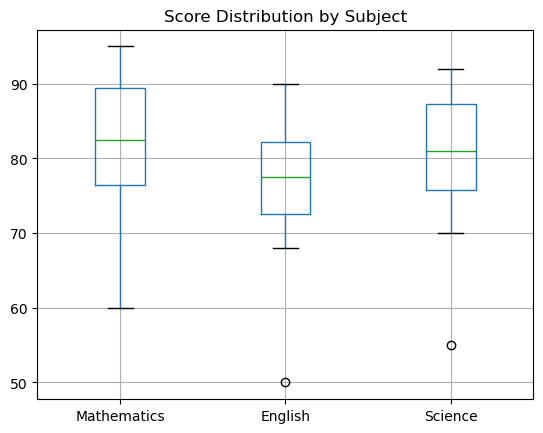

In [37]:
import matplotlib.pyplot as plt

df[['Mathematics','English','Science']].boxplot()
plt.title("Score Distribution by Subject")

plt.show()
